# 05 — Exponential Decay-Weighted Historical VaR

**Lesson:** Equal-weighted historical VaR treats every day in the window identically — a return from 252 days ago gets the same vote as yesterday's. This is the root cause of the regime-change lag we saw in notebook 03. Decay weighting gives more influence to recent returns, producing faster reactions without introducing a hard window cliff.

This notebook answers: *can we make VaR react faster to new risk without abandoning the historical method?*

## ⚙️ Parameters

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
WINDOW = 252
CONFIDENCE = 0.95
LAMBDA = 0.94       # decay factor — 0.94 is the RiskMetrics standard

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.decay import decay_var
from src.rolling import rolling_var, rolling_decay_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

---

## Part A: How decay weights work

The weight for a return that happened $t$ days ago is $\lambda^t$. Normalised to sum to 1 across the window.

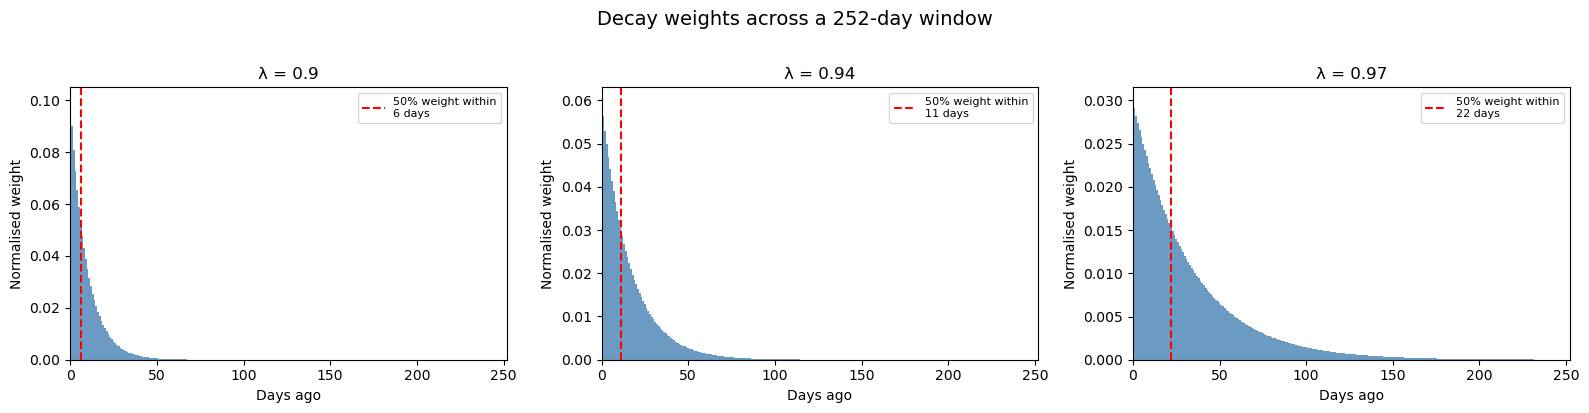

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lambdas = [0.90, 0.94, 0.97]
ages = np.arange(252)

for ax, lam in zip(axes, lambdas):
    weights = lam ** ages
    weights = weights / weights.sum()

    ax.bar(ages, weights, width=1, alpha=0.8, color="steelblue")
    ax.axvline(np.where(np.cumsum(weights) > 0.5)[0][0], color="red", linestyle="--",
              label=f"50% weight within\n{np.where(np.cumsum(weights) > 0.5)[0][0]} days")
    ax.set_xlabel("Days ago")
    ax.set_ylabel("Normalised weight")
    ax.set_title(f"λ = {lam}")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 252)

plt.suptitle("Decay weights across a 252-day window", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### What this shows

- **λ=0.90:** Aggressive decay. 50% of total weight is in the most recent ~7 days. Effectively a short-term view.
- **λ=0.94:** RiskMetrics standard. 50% of weight in ~12 days. Balanced.
- **λ=0.97:** Slow decay. 50% in ~23 days. Closer to equal-weighted.

The key: no hard cutoff. Returns from 3 months ago still contribute — just very little.

---

## Part B: Equal vs decay on SPY

The core comparison: equal-weighted 252d VaR vs decay-weighted (λ=0.94) on the same data.

In [4]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)

eq_result = rolling_var(returns, window=WINDOW, confidence=CONFIDENCE)
dc_result = rolling_decay_var(returns, window=WINDOW, lam=LAMBDA, confidence=CONFIDENCE)

print(f"Equal-weighted:     {eq_result['Breach'].sum()} breaches ({eq_result['Breach'].mean():.3%})")
print(f"Decay-weighted (λ={LAMBDA}): {dc_result['Breach'].sum()} breaches ({dc_result['Breach'].mean():.3%})")

Prepared 2144 daily returns (2018-01-03 to 2026-07-16) from 2145 price observations.


Equal-weighted:     90 breaches (4.757%)
Decay-weighted (λ=0.94): 113 breaches (5.973%)


### Overlay: which reacts faster?

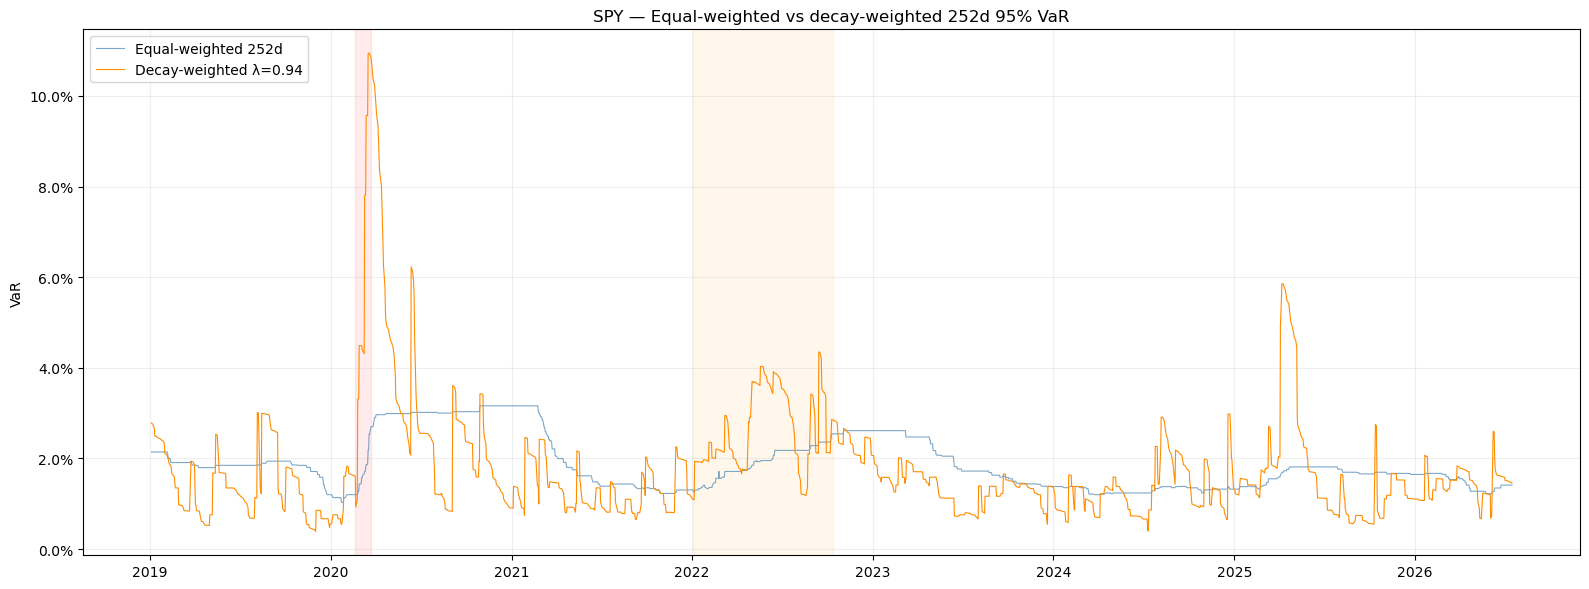

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(eq_result.index, eq_result["VaR"], linewidth=0.8, color="steelblue",
        alpha=0.7, label=f"Equal-weighted {WINDOW}d")
ax.plot(dc_result.index, dc_result["VaR"], linewidth=0.8, color="darkorange",
        label=f"Decay-weighted λ={LAMBDA}")

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
           alpha=0.08, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-12"),
           alpha=0.08, color="orange")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — Equal-weighted vs decay-weighted {WINDOW}d {CONFIDENCE:.0%} VaR")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Zoom: COVID crash — who reacted first?

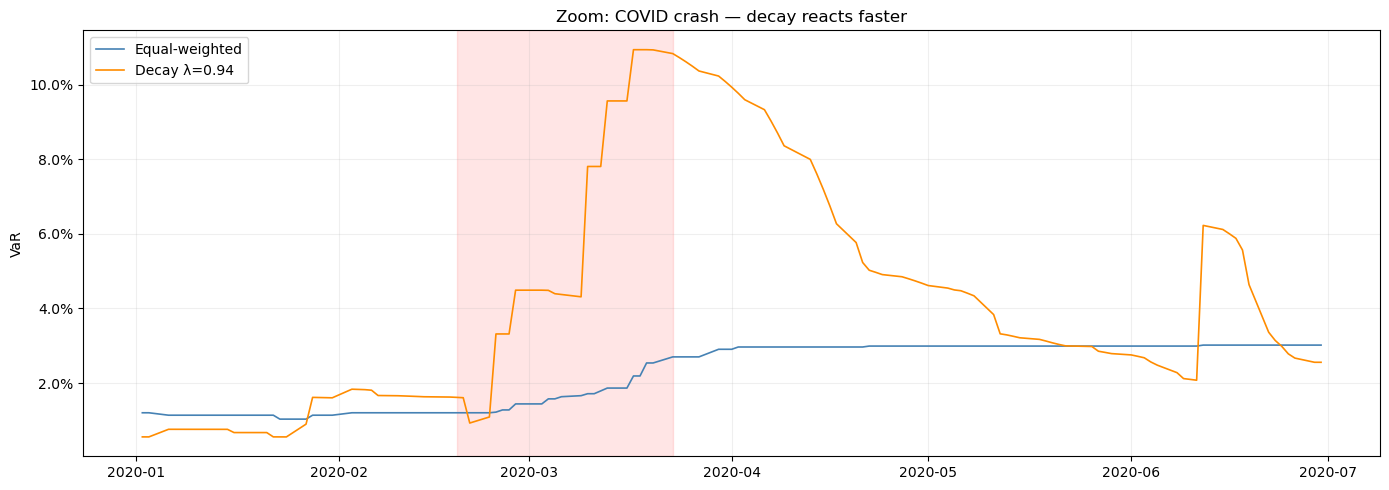

Equal-weighted    : Pre-crash VaR = 1.202%, doubled in 29 calendar days
Decay-weighted    : Pre-crash VaR = 1.615%, doubled in 6 calendar days


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

zoom_start = pd.Timestamp("2020-01-02")
zoom_end = pd.Timestamp("2020-06-30")

mask_eq = (eq_result.index >= zoom_start) & (eq_result.index <= zoom_end)
mask_dc = (dc_result.index >= zoom_start) & (dc_result.index <= zoom_end)

ax.plot(eq_result.index[mask_eq], eq_result["VaR"][mask_eq],
        linewidth=1.2, color="steelblue", label="Equal-weighted")
ax.plot(dc_result.index[mask_dc], dc_result["VaR"][mask_dc],
        linewidth=1.2, color="darkorange", label=f"Decay λ={LAMBDA}")

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"),
           alpha=0.1, color="red")

ax.set_ylabel("VaR")
ax.set_title("Zoom: COVID crash — decay reacts faster")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Timing comparison
crash_start = pd.Timestamp("2020-02-19")
for name, res in [("Equal-weighted", eq_result), ("Decay-weighted", dc_result)]:
    post = res.loc[crash_start:]
    # Pre-crash VaR
    pre_var = res.loc[:crash_start, "VaR"].iloc[-1]
    # Days to double
    threshold = pre_var * 2
    spike = post[post["VaR"] > threshold]
    if len(spike) > 0:
        days = (spike.index[0] - crash_start).days
        print(f"{name:<18}: Pre-crash VaR = {pre_var:.3%}, doubled in {days} calendar days")

---

## Part C: Lambda sensitivity

λ controls the trade-off between recency and stability. Let's see the full range.

In [7]:
lambdas = [0.90, 0.94, 0.97, 0.99]
dc_results = {}

for lam in lambdas:
    dc_results[lam] = rolling_decay_var(returns, window=WINDOW, lam=lam, confidence=CONFIDENCE)
    print(f"λ={lam:.2f}: {dc_results[lam]['Breach'].sum()} breaches ({dc_results[lam]['Breach'].mean():.3%})")

λ=0.90: 139 breaches (7.347%)


λ=0.94: 113 breaches (5.973%)


λ=0.97: 107 breaches (5.655%)


λ=0.99: 91 breaches (4.810%)


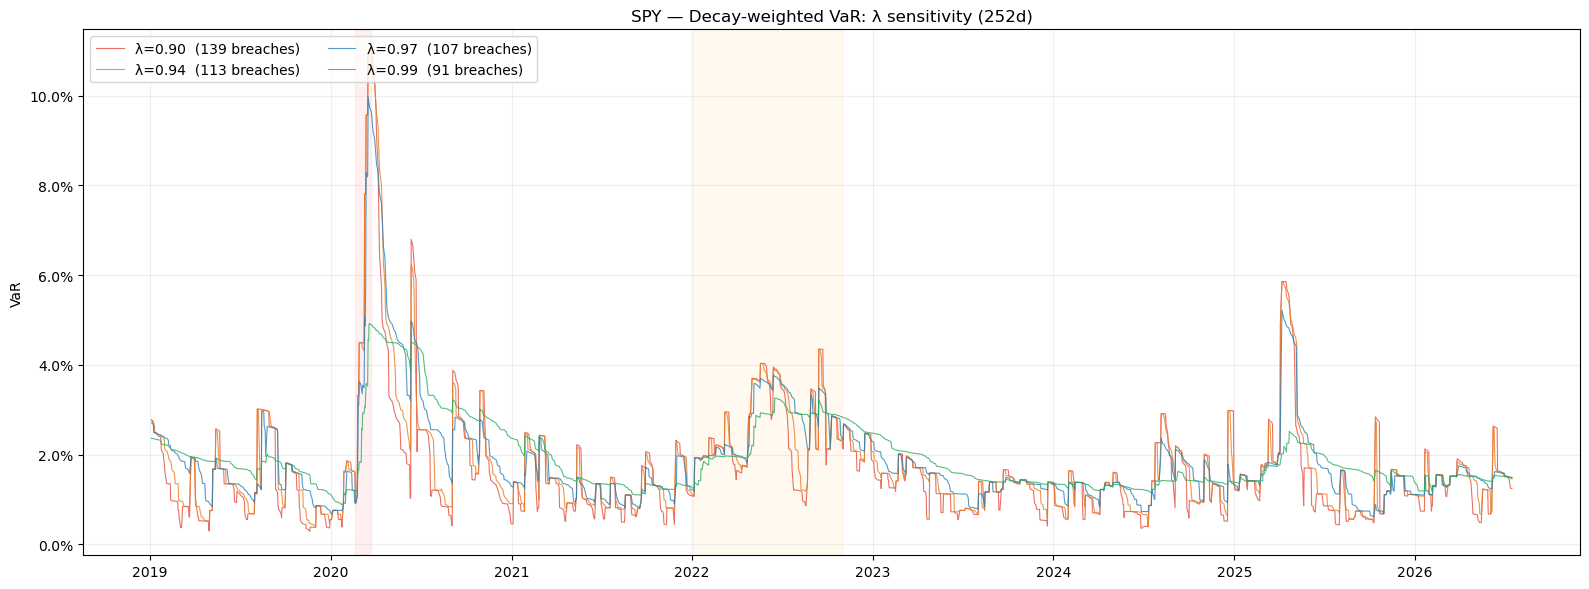

In [8]:
colors_lam = {0.90: "#e74c3c", 0.94: "#e67e22", 0.97: "#2980b9", 0.99: "#27ae60"}

fig, ax = plt.subplots(figsize=(16, 6))

for lam in lambdas:
    ax.plot(dc_results[lam].index, dc_results[lam]["VaR"],
            linewidth=0.8, alpha=0.8, color=colors_lam[lam],
            label=f"λ={lam:.2f}  ({dc_results[lam]['Breach'].sum()} breaches)")

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — Decay-weighted VaR: λ sensitivity ({WINDOW}d)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left", ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Reading λ

| λ | Behaviour | Effective lookback |
|----|-----------|-------------------|
| 0.90 | Aggressive — reacts to every market twitch. High breach count. | ~20 days |
| 0.94 | RiskMetrics standard. Good balance of speed and stability. | ~75 days |
| 0.97 | Conservative — closer to equal-weighted but still favours recent data. | ~150 days |
| 0.99 | Near-equal — very slow to react, similar to the 252d fixed window. | ~250 days |

There is no correct λ — like the window size, it's a choice that trades off recency against noise.

---

## Part D: Window cliff elimination

The synthetic example from notebook 04: a single -10% return in a sea of zeros. With equal weighting, VaR jumps from 0 to 5.1% the day after the loss enters, then drops back to 0 exactly 50 days later. Decay weighting smooths this.

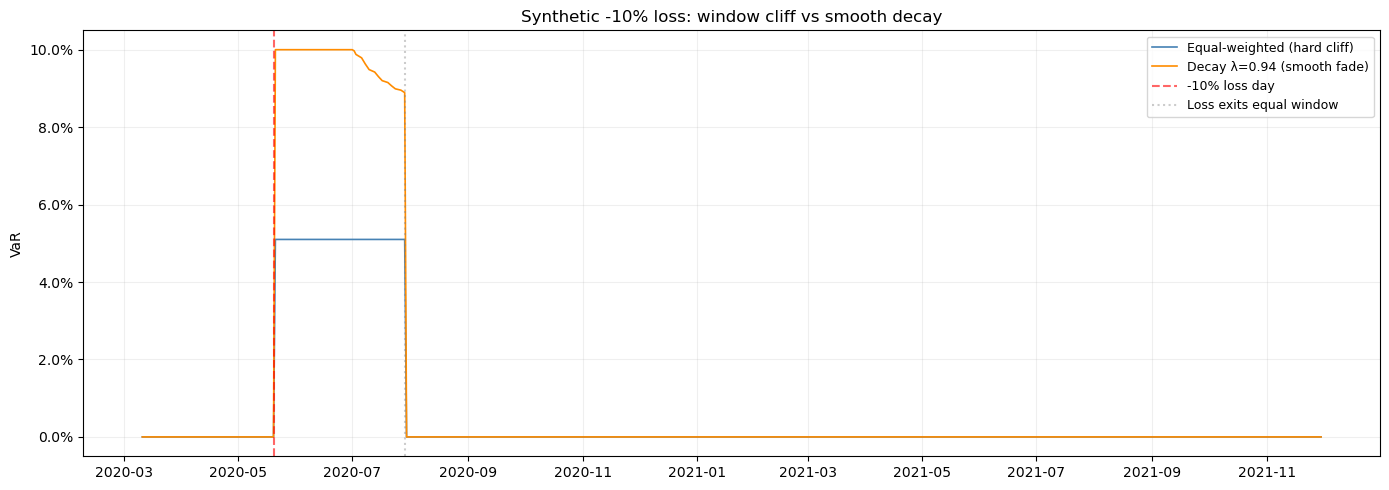

In [9]:
n_days = 500
loss_idx = 100
syn = np.zeros(n_days)
syn[loss_idx] = -0.10
dates_syn = pd.date_range("2020-01-01", periods=n_days, freq="B")
returns_syn = pd.Series(syn, index=dates_syn)

syn_window = 50
eq_syn = rolling_var(returns_syn, window=syn_window, confidence=0.99)
dc_syn = rolling_decay_var(returns_syn, window=syn_window, lam=0.94, confidence=0.99)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(eq_syn.index, eq_syn["VaR"], linewidth=1.2, color="steelblue", label="Equal-weighted (hard cliff)")
ax.plot(dc_syn.index, dc_syn["VaR"], linewidth=1.2, color="darkorange", label="Decay λ=0.94 (smooth fade)")

ax.axvline(dates_syn[loss_idx], color="red", linestyle="--", alpha=0.6, label=f"-10% loss day")
ax.axvline(dates_syn[loss_idx + syn_window], color="gray", linestyle=":", alpha=0.4,
          label=f"Loss exits equal window")

ax.set_ylabel("VaR")
ax.set_title(f"Synthetic -10% loss: window cliff vs smooth decay")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What this shows

- **Equal-weighted:** VaR is exactly 0 before the loss enters the window, jumps to a flat plateau while the loss is in the window, and drops back to 0 the day the loss exits. This is mechanical, not a reflection of changing risk.
- **Decay-weighted:** VaR rises when the loss enters, peaks when the loss is most recent (highest weight), then gradually fades as the loss ages. No cliff — no day where VaR abruptly drops.

The decay-weighted behaviour is more realistic. In real markets, extreme events don't suddenly become irrelevant after exactly 252 days. Their relevance fades gradually.

---

## Key insight

Decay weighting doesn't fix the stationarity problem — it just shortens the effective lookback without a hard cliff. The λ parameter trades off recency against stability, similar to how window size does for equal-weighted VaR.

The production approach (as RiskMetrics established in the 1990s) is:
- Use λ=0.94 for daily data (standard)
- Use a long window (252d or more) so old data is available — decay will naturally downweight it
- Compare decay-weighted VaR with equal-weighted — the gap between them IS the signal that recent data is telling a different story

Next steps: volatility-scaled historical VaR (mitigation 2 from the production playbook), or portfolio-level VaR.